### 2 – Signal Preprocessing

##### Theory & Industrial Relevance
Real UT signals are contaminated by electrical noise, coupling variability, and material grain scattering. Preprocessing is mandatory before feature extraction or modelling. Industrial systems often implement real‑time filters (low‑pass to remove high‑frequency noise, high‑pass to suppress DC offset or low‑frequency mechanical vibrations, band‑pass to isolate the transducer’s frequency band).
Wavelet denoising is particularly effective because ultrasonic echoes are transient events; wavelets can separate signal and noise in both time and frequency. Savitzky‑Golay preserves peak shapes while smoothing.
Scaling ensures consistent magnitude across different transducers or gain settings.

**Mathematical intuition**



##### 1. Butterworth Filtering

Butterworth filters provide a maximally flat frequency response in the passband and are commonly used to remove high-frequency noise while preserving signal characteristics.

##### 2. Wavelet Thresholding

Wavelet denoising removes noise by thresholding wavelet coefficients. Coefficients below a threshold are set to zero.

The universal threshold is given by:

$$
\lambda = \sigma \sqrt{2 \log N}
$$

where:

- $\lambda$ = threshold value
- $\sigma$ = estimated noise standard deviation
- $N$ = number of samples

##### 3. Min-Max Scaling

Signal amplitudes are normalized to the range $[0,1]$ using Min-Max scaling:

$$
x' = \frac{x - \min(x)}{\max(x) - \min(x)}
$$

where:

- $x$ = original value
- $x'$ = normalized value
- $\min(x)$ = minimum value in the dataset
- $\max(x)$ = maximum value in the dataset




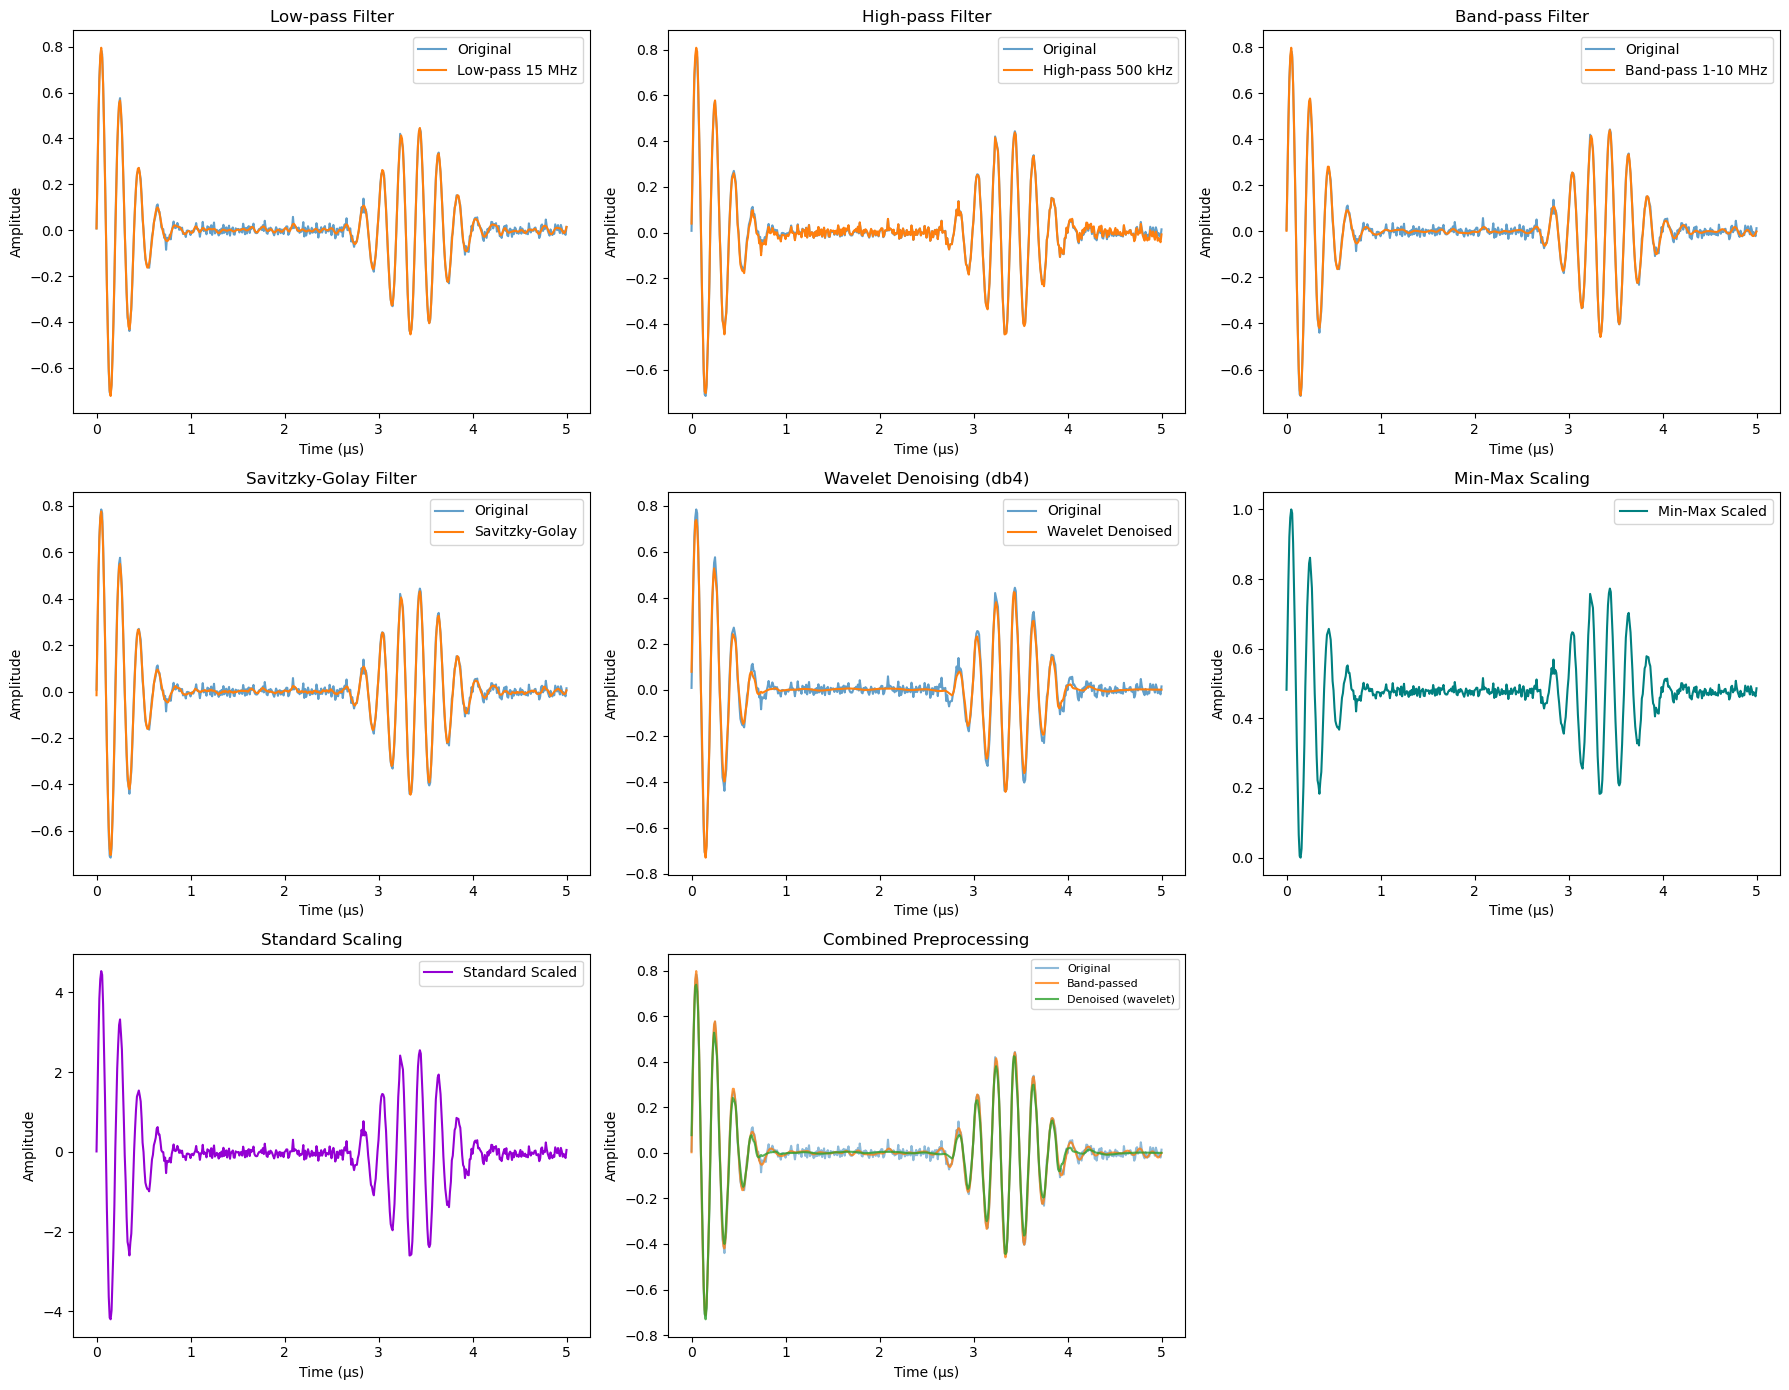

In [1]:
# ====================================================
# Notebook 02: Signal Preprocessing
# ====================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from scipy.signal import butter, filtfilt, savgol_filter
import pywt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from pathlib import Path

# Load raw data
with open("../data/raw/signals.pkl", "rb") as f:
    signals_list, labels_list, TIME = pickle.load(f)

SIGNAL_LENGTH = len(TIME)
# Convert to array for easy manipulation
signals_array = np.array(signals_list)

# ====================================================
# Filtering functions
# ====================================================
def butter_lowpass(cutoff: float, fs: float, order: int = 5) -> tuple:
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def butter_highpass(cutoff: float, fs: float, order: int = 5) -> tuple:
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def butter_bandpass(lowcut: float, highcut: float, fs: float, order: int = 5) -> tuple:
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def apply_filter(data: np.ndarray, b: np.ndarray, a: np.ndarray) -> np.ndarray:
    """Zero‑phase filtering using filtfilt."""
    return filtfilt(b, a, data)

# Parameters
FS = 1 / (TIME[1] - TIME[0])  # 100 MHz
LOWPASS_CUTOFF = 15e6          # 15 MHz
HIGHPASS_CUTOFF = 500e3        # 500 kHz
BAND_LOW, BAND_HIGH = 1e6, 10e6  # 1‑10 MHz
SAVGOL_WINDOW = 11
SAVGOL_ORDER = 3
WAVELET = 'db4'
WAVELET_LEVEL = 4

# Select a sample signal (Normal class, index 0)
sample_idx = 0
original = signals_array[sample_idx]

# Low‑pass
b_low, a_low = butter_lowpass(LOWPASS_CUTOFF, FS, order=6)
lowpassed = apply_filter(original, b_low, a_low)

# High‑pass
b_high, a_high = butter_highpass(HIGHPASS_CUTOFF, FS, order=6)
highpassed = apply_filter(original, b_high, a_high)

# Band‑pass
b_band, a_band = butter_bandpass(BAND_LOW, BAND_HIGH, FS, order=6)
bandpassed = apply_filter(original, b_band, a_band)

# Savitzky‑Golay
savgol_filtered = savgol_filter(original, window_length=SAVGOL_WINDOW, polyorder=SAVGOL_ORDER)

# Wavelet denoising
coeffs = pywt.wavedec(original, WAVELET, level=WAVELET_LEVEL)
# Universal threshold
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(len(original)))
denoised_coeffs = [coeffs[0]]  # keep approximation
for detail in coeffs[1:]:
    denoised_coeffs.append(pywt.threshold(detail, threshold, mode='soft'))
wavelet_denoised = pywt.waverec(denoised_coeffs, WAVELET)
# Ensure same length
wavelet_denoised = wavelet_denoised[:len(original)]

# Normalisation / Scaling
scaler_minmax = MinMaxScaler()
scaler_standard = StandardScaler()
original_2d = original.reshape(-1, 1)
minmax_scaled = scaler_minmax.fit_transform(original_2d).flatten()
standard_scaled = scaler_standard.fit_transform(original_2d).flatten()

# ====================================================
# Visualisations
# ====================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
time_us = TIME * 1e6

# Row 1: filtering
axes[0].plot(time_us, original, label='Original', alpha=0.7)
axes[0].plot(time_us, lowpassed, label='Low‑pass 15 MHz', linewidth=1.5)
axes[0].set_title("Low‑pass Filter")
axes[0].legend(loc='upper right')
axes[0].set_xlabel("Time (µs)"); axes[0].set_ylabel("Amplitude")

axes[1].plot(time_us, original, label='Original', alpha=0.7)
axes[1].plot(time_us, highpassed, label='High‑pass 500 kHz', linewidth=1.5)
axes[1].set_title("High‑pass Filter")
axes[1].legend(loc='upper right')
axes[1].set_xlabel("Time (µs)"); axes[1].set_ylabel("Amplitude")

axes[2].plot(time_us, original, label='Original', alpha=0.7)
axes[2].plot(time_us, bandpassed, label='Band‑pass 1‑10 MHz', linewidth=1.5)
axes[2].set_title("Band‑pass Filter")
axes[2].legend(loc='upper right')
axes[2].set_xlabel("Time (µs)"); axes[2].set_ylabel("Amplitude")

# Row 2: noise reduction
axes[3].plot(time_us, original, label='Original', alpha=0.7)
axes[3].plot(time_us, savgol_filtered, label='Savitzky‑Golay', linewidth=1.5)
axes[3].set_title("Savitzky‑Golay Filter")
axes[3].legend(loc='upper right')
axes[3].set_xlabel("Time (µs)"); axes[3].set_ylabel("Amplitude")

axes[4].plot(time_us, original, label='Original', alpha=0.7)
axes[4].plot(time_us, wavelet_denoised, label='Wavelet Denoised', linewidth=1.5)
axes[4].set_title("Wavelet Denoising (db4)")
axes[4].legend(loc='upper right')
axes[4].set_xlabel("Time (µs)"); axes[4].set_ylabel("Amplitude")

# Row 3: scaling
axes[5].plot(time_us, minmax_scaled, label='Min‑Max Scaled', color='teal')
axes[5].set_title("Min‑Max Scaling")
axes[5].legend(loc='upper right')
axes[5].set_xlabel("Time (µs)"); axes[5].set_ylabel("Amplitude")

axes[6].plot(time_us, standard_scaled, label='Standard Scaled', color='darkviolet')
axes[6].set_title("Standard Scaling")
axes[6].legend(loc='upper right')
axes[6].set_xlabel("Time (µs)"); axes[6].set_ylabel("Amplitude")

# Combination view
axes[7].plot(time_us, original, label='Original', alpha=0.5)
axes[7].plot(time_us, bandpassed, label='Band‑passed', alpha=0.8)
axes[7].plot(time_us, wavelet_denoised, label='Denoised (wavelet)', alpha=0.8)
axes[7].set_title("Combined Preprocessing")
axes[7].legend(loc='upper right', fontsize=8)
axes[7].set_xlabel("Time (µs)"); axes[7].set_ylabel("Amplitude")

# Remove empty axis
axes[8].axis('off')
plt.tight_layout()
plt.savefig("../images/preprocessing_demo.png", dpi=300)
plt.show()

##### Interpretation of Result

Low‑pass filter smooths high‑frequency noise but may blur sharp crack peaks.

High‑pass removes DC baseline drift.

Band‑pass isolates the transducer’s active frequency range – retains defect echoes while rejecting out‑of‑band noise.

Wavelet denoising preserves transient echoes better than linear filtering.

Scaling is essential before feeding data into machine learning models that assume similar input ranges.